In [8]:
# Import libraries for NLP, Deep Learning, and Evaluation
import os
import pandas as pd
import numpy as np
import requests
import re
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Global NLP Configs
MAX_LEN = 20
OOV_TOKEN = "<OOV>"

In [9]:
# Text cleaning, Data Augmentation, and Dataset Fusion
def clean_arabic_text(text):
    text = str(text)
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    text = re.sub(r'[^\w\s\u0600-\u06FF]', '', text)
    text = re.sub(r'[أإآ]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    return text.strip()

all_data = []


conversational_data = [
    {"Query": "مرحبا", "Intent": "ترحيب", "Response": "أهلاً بك في نور بوت! تفضل واسألني عن الأحاديث والأذكار."},
    {"Query": "السلام عليكم", "Intent": "ترحيب", "Response": "وعليكم السلام ورحمة الله وبركاته! أهلاً بك."},
    {"Query": "سلام", "Intent": "ترحيب", "Response": "أهلاً بك في نور بوت! كيف يمكنني مساعدتك؟"},
    {"Query": "هلا", "Intent": "ترحيب", "Response": "يا هلا بك! تفضل واسألني."},
    {"Query": "صباح الخير", "Intent": "ترحيب", "Response": "صباح النور والسرور! كيف يمكنني مساعدتك اليوم؟"},
    {"Query": "مساء الخير", "Intent": "ترحيب", "Response": "مساء النور! هل تبحث عن دعاء أو حديث معين؟"},

    {"Query": "من انت", "Intent": "تعريف", "Response": "أنا نور بوت (NoorBot)، صُممت لمساعدتك في الوصول للأدعية والأحاديث النبوية بسهولة."},
    {"Query": "وش اسمك", "Intent": "تعريف", "Response": "اسمي نور بوت، أنا مساعدك الآلي للمحتوى الإسلامي."},
    {"Query": "ايش تسوي", "Intent": "تعريف", "Response": "أنا أساعدك في العثور على الأحاديث النبوية والأذكار والأدعية التي تبحث عنها."},
    {"Query": "كيف تساعدني", "Intent": "تعريف", "Response": "يمكنك سؤالي عن أي دعاء أو حديث، وسأقوم بالبحث عنه وإعطائك الإجابة."},

    {"Query": "مع السلامه", "Intent": "وداع", "Response": "في أمان الله! لا تتردد في العودة إذا احتجت لأي مساعدة."},
    {"Query": "شكرا", "Intent": "وداع", "Response": "العفو! سعدت بخدمتك، ولا تنسَ ذكر الله."},
    {"Query": "يعطيك العافيه", "Intent": "وداع", "Response": "الله يعافيك! في أمان الله."},
    {"Query": "وداعا", "Intent": "وداع", "Response": "استودعك الله الذي لا تضيع ودائعه."},
    {"Query": "جزاك الله خير", "Intent": "وداع", "Response": "وإياك يا رب! في أمان الله."}
]
all_data.extend(conversational_data)


query_templates = ["", "اريد ", "ابي ", "دعاء ", "حديث عن "]

# Fetch Adhkar dataset from GitHub
try:
    url = "https://raw.githubusercontent.com/rn0x/Adhkar-json/master/adhkar.json"
    data_json = requests.get(url).json()

    # Data Augmentation to cover critical topics
    data_json.extend([
        {"category": "دعاء المطر", "array": [{"text": "اللهم صيباً نافعاً."}]},
        {"category": "حديث الاعمال بالنيات", "array": [{"text": "قال رسول الله ﷺ: (إنما الأعمال بالنيات، وإنما لكل امرئ ما نوى)."}]},
        {"category": "حديث بر الوالدين", "array": [{"text": "قال رسول الله ﷺ: (رغم أنف.. من أدرك أبويه عند الكبر فلم يدخل الجنة)."}]},
        {"category": "حديث حسن الخلق", "array": [{"text": "قال رسول الله ﷺ: (إن من أحبكم إلي وأقربكم مني مجلسا يوم القيامة أحاسنكم أخلاقا)."}]},
        {"category": "أحاديث الصلاة", "array": [{"text": "قال رسول الله ﷺ: (صلوا كما رأيتموني أصلي)."}]}
    ])

    for item in data_json:
        cat = item.get('category', 'General')
        for entry in item.get('array', []):
            for t in query_templates:
                q = t + cat.replace("دعاء ", "").replace("أحاديث ", "")
                all_data.append({"Query": q, "Intent": cat, "Response": entry.get('text', '')})
    print("GitHub Adhkar, custom conversational intents, and augmented data loaded successfully.")
except Exception as e:
    print("GitHub fetching error:", e)

# Fetch Kaggle Hadith Datasets
kaggle_files = [
    'ahmad_qa_pair.json',
    'bukhari_qa_pair.json',
    'muslim_qa_pair.json',
    'tirmidhi_qa_pair.json'
]

for file_name in kaggle_files:
    if os.path.exists(file_name):
        try:
            hadith_df = pd.read_json(file_name)
            for _, row in hadith_df.iterrows():
                question = row.get('Question', row.get('question', ''))
                answer = row.get('Answer', row.get('answer', ''))
                if question and answer:
                    all_data.append({"Query": question, "Intent": "سؤال حديث", "Response": answer})
            print(f"Kaggle file loaded: {file_name}")
        except Exception as e:
            print(f"Error loading {file_name}:", e)

# Build Final DataFrame
df = pd.DataFrame(all_data)
df['Clean_Query'] = df['Query'].apply(clean_arabic_text)
df = df[df['Clean_Query'].str.len() > 1]
print(f"Total samples fused: {len(df)}")

GitHub Adhkar, custom conversational intents, and augmented data loaded successfully.
Kaggle file loaded: ahmad_qa_pair.json
Kaggle file loaded: bukhari_qa_pair.json
Kaggle file loaded: muslim_qa_pair.json
Kaggle file loaded: tirmidhi_qa_pair.json
Total samples fused: 1375


In [10]:
# TF-IDF Vectorization and Train-Test Split
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(df['Clean_Query'])

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Intent'])

tokenizer = Tokenizer(oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df['Clean_Query'])
X = pad_sequences(tokenizer.texts_to_sequences(df['Clean_Query']), maxlen=MAX_LEN, padding='post')
y = df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Build and Train BiLSTM Neural Network
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(enumerate(weights))

model = Sequential([
    Embedding(len(tokenizer.word_index) + 1, 64),
    Bidirectional(LSTM(64)),
    Dropout(0.6),
    Dense(32, activation='relu'),
    Dropout(0.6),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Starting BiLSTM model training...")
model.fit(X_train, y_train, epochs=150, validation_data=(X_test, y_test),
          callbacks=[early_stop], class_weight=weight_dict, verbose=1)
print("Training completed.")

Starting BiLSTM model training...
Epoch 1/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.0155 - loss: 4.9466 - val_accuracy: 0.0364 - val_loss: 4.9340
Epoch 2/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0164 - loss: 4.9404 - val_accuracy: 0.1709 - val_loss: 4.9233
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.0282 - loss: 4.9418 - val_accuracy: 0.1491 - val_loss: 4.9109
Epoch 4/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.0564 - loss: 4.9290 - val_accuracy: 0.1455 - val_loss: 4.8742
Epoch 5/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0718 - loss: 4.9194 - val_accuracy: 0.1600 - val_loss: 4.7691
Epoch 6/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1145 - loss: 4.8617 - val_accuracy: 0.1782 - val_loss: 4.3716
Epoch 7/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.1236 - loss: 4.7724 - val_accuracy: 0.1709 - val_loss: 4.0031
Epoch 8/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1218

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
 Performance Metrics Summary 
 Overall Accuracy : 1.0000  (100.00%)
 Precision        : 1.0000  (100.00%)
 Recall           : 1.0000  (100.00%)
 F1-Score         : 1.0000  (100.00%)

--- Detailed Classification Report ---
                                                              precision    recall  f1-score   support

                                               أحاديث الصلاة       0.00      0.00      0.00         0
                                                أذكار الآذان       1.00      1.00      1.00         4
                                    أذكار الاستيقاظ من النوم       1.00      1.00      1.00         3
                                        أذكار الصباح والمساء       1.00      1.00      1.00        25
                                                 أذكار النوم       1.00      1.00      1.00         9
                                                إفشاء السلام       1.00      1.00      1.00         3
                         

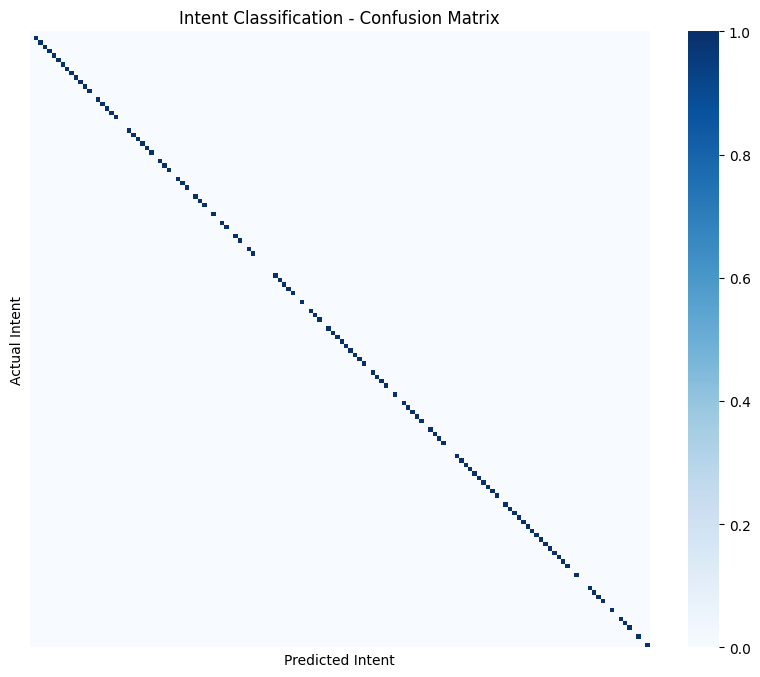

In [12]:
# Model Evaluation and Confusion Matrix Generation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Generate predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Print Summary Metrics
print("="*50)
print(" Performance Metrics Summary ")
print("="*50)
print(f" Overall Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f" Precision        : {precision:.4f}  ({precision*100:.2f}%)")
print(f" Recall           : {recall:.4f}  ({recall*100:.2f}%)")
print(f" F1-Score         : {f1:.4f}  ({f1*100:.2f}%)")
print("="*50)

# Print Detailed Classification Report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, labels=np.arange(len(le.classes_)), target_names=le.classes_, zero_division=0))

# Plot Confusion Matrix
plt.figure(figsize=(10,8))
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(le.classes_)), normalize='true')
sns.heatmap(cm, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title("Intent Classification - Confusion Matrix")
plt.ylabel('Actual Intent')
plt.xlabel('Predicted Intent')
plt.show()

In [13]:
# Evaluate model on training data
y_train_pred = np.argmax(model.predict(X_train), axis=1)
train_acc = accuracy_score(y_train, y_train_pred)

# Evaluate model on testing data
test_acc = accuracy_score(y_test, y_pred)

print("--- Overfitting Analysis ---")
print(f"Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Testing Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print("-" * 28)

difference = train_acc - test_acc
print(f"Difference        : {difference:.4f}")

if difference > 0.10:
    print("Conclusion: Potential overfitting detected. Model struggles with unseen data.")
else:
    print("Conclusion: No severe overfitting. Model generalizes well to unseen data.")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
--- Overfitting Analysis ---
Training Accuracy : 1.0000 (100.00%)
Testing Accuracy  : 1.0000 (100.00%)
----------------------------
Difference        : 0.0000
Conclusion: No severe overfitting. Model generalizes well to unseen data.


In [14]:
# Response Generation (Retrieval-based approach)
def get_noor_response(user_input):
    cleaned = clean_arabic_text(user_input)

    # 1. DL Intent Prediction
    seq = pad_sequences(tokenizer.texts_to_sequences([cleaned]), maxlen=MAX_LEN, padding='post')
    pred = model.predict(seq, verbose=0)
    conf = np.max(pred)
    predicted_intent = le.inverse_transform([np.argmax(pred)])[0]

    # 2. Retrieval-based mechanism (TF-IDF & Cosine Similarity as per PDF)
    user_tfidf = tfidf_vec.transform([cleaned])
    similarities = cosine_similarity(user_tfidf, tfidf_matrix)
    best_match_idx = np.argmax(similarities)
    best_score = similarities[0, best_match_idx]

    # Priority for TF-IDF Similarity on Hadiths or low DL confidence
    if "حديث" in cleaned or predicted_intent == "سؤال حديث" or conf < 0.45:
        if best_score > 0.15:
            return df.iloc[best_match_idx]['Response']
        return "I couldn't find an exact match in the database. (عذراً، بحثت ولم أجد تطابقاً دقيقاً)"

    # Fallback to random response from the predicted intent class (for general Adhkar)
    responses = df[df['Intent'] == predicted_intent]['Response'].tolist()
    return random.choice(responses)

# Interactive Chat Loop
print("NoorBot is ready! Type 'خروج' to stop.")
while True:
    u_msg = input("You: ")
    if u_msg == 'خروج': break
    print(f"Bot: {get_noor_response(u_msg)}\n")

NoorBot is ready! Type 'خروج' to stop.
You: السلام عليكم 
Bot: أهلاً بك في نور بوت! تفضل واسألني عن الأحاديث والأذكار.

You: من انت
Bot: يمكنك سؤالي عن أي دعاء أو حديث، وسأقوم بالبحث عنه وإعطائك الإجابة.

You: دعاء المطر
Bot: اللهم صيباً نافعاً.

You: دعاء السفر
Bot: اللَّهُ أَكْبَرُ، اللَّهُ أَكْبَرُ، اللَّهُ أَكْبَرُ، ﴿سُبْحَانَ الَّذِي سَخَّرَ لَنَا هَذَا وَمَا كُنَّا لَهُ مُقْرِنِينَ * وَإِنَّا إِلَى رَبِّنَا لَمُنقَلِبُونَ﴾ ((اللَّهُمَّ إِنّا نَسْأَلُكَ فِي سَفَرِنَا هَذَا البِرَّ وَالتَّقْوَى، وَمِنَ الْعَمَلِ مَا تَرْضَى، اللَّهُمَّ هَوِّنْ عَلَيْنَا سَفَرَنَا هَذَا وَاطْوِ عَنَّا بُعْدَهُ، اللَّهُمَّ أَنْتَ الصَّاحِبُ فِي السَّفَرِ، وَالْخَليفَةُ فِي الْأَهْلِ، اللَّهُمَّ إِنِّي أَعُوذُ بِكَ مِنْ وَعْثَاءِ السَّفَرِ، وَكَآبَةِ الْمَنْظَرِ، وَسُوءِ الْمُنْقَلَبِ فِي الْمَالِ وَالْأَهْلِ))، وإذا رَجَعَ قَالَهُنَّ وَزَادَ فِيهِنَّ: ((آيِبُونَ، تائِبُونَ، عَابِدُونَ، لِرَبِّنَا حَامِدُونَ)).

You: شكرا
Bot: العفو! سعدت بخدمتك، ولا تنسَ ذكر الله.

You: خروج
